In [1]:
# Local PyCharm / Jupyter setup
from local_setup import prepare
prepare()


Project: E:\Deeplearning\111\assignment1_colab\assignment1
Python: D:\Wei\python_3.12\python.exe
CIFAR-10 ready.


# Image features exercise
*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.

In [2]:
import random
import numpy as np
np.random.seed(0)
random.seed(0)
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [3]:
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

E:\Deeplearning\111\assignment1_colab\assignment1\cs231n\data_utils.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.

In [4]:
from cs231n.features import *

# num_color_bins = 10 # Number of bins in the color histogram
num_color_bins = 25 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
std_feat = np.maximum(std_feat, 1e-12)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])
assert all(np.isfinite(a).all() for a in (X_train_feats, X_val_feats, X_test_feats))
print("Feature matrix shapes:", X_train_feats.shape, X_val_feats.shape, X_test_feats.shape)


Done extracting features for 1000 / 49000 images


Done extracting features for 2000 / 49000 images


Done extracting features for 3000 / 49000 images


Done extracting features for 4000 / 49000 images


Done extracting features for 5000 / 49000 images


...

Done extracting features for 46000 / 49000 images


Done extracting features for 47000 / 49000 images


Done extracting features for 48000 / 49000 images


Done extracting features for 49000 / 49000 images


Feature matrix shapes: (49000, 170) (1000, 170) (1000, 170)


## Train Softmax classifier on features
Using the Softmax code developed earlier in the assignment, train Softmax classifiers on top of the features extracted above; this should achieve better results than training them directly on top of raw pixels.

In [5]:
from cs231n.classifiers.linear_classifier import Softmax
# Standardized features require different hyperparameters from raw pixels.
learning_rates = [0.03, 0.1, 0.3]
regularization_strengths = [0.001, 0.01]
results = {}
best_val = -1
best_softmax = None
for lr in learning_rates:
    for reg in regularization_strengths:
        np.random.seed(42)
        candidate = Softmax()
        candidate.train(X_train_feats, y_train, learning_rate=lr, reg=reg,
                        num_iters=2000, batch_size=200)
        train_acc = np.mean(candidate.predict(X_train_feats) == y_train)
        val_acc = np.mean(candidate.predict(X_val_feats) == y_val)
        results[(lr, reg)] = (train_acc, val_acc)
        print('lr=%g reg=%g train=%f validation=%f' % (lr, reg, train_acc, val_acc))
        if val_acc > best_val:
            best_val, best_softmax = val_acc, candidate
print('Best validation accuracy:', best_val)
assert best_val > 0.42


lr=0.03 reg=0.001 train=0.523980 validation=0.517000


lr=0.03 reg=0.01 train=0.520245 validation=0.510000


lr=0.1 reg=0.001 train=0.520592 validation=0.517000


lr=0.1 reg=0.01 train=0.515265 validation=0.502000


lr=0.3 reg=0.001 train=0.508633 validation=0.494000


lr=0.3 reg=0.01 train=0.500510 validation=0.492000
Best validation accuracy: 0.517


In [6]:
# Evaluate your trained Softmax on the test set: you should be able to get at least 0.42
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.506

In [7]:
# Save best softmax model
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy

 saved.


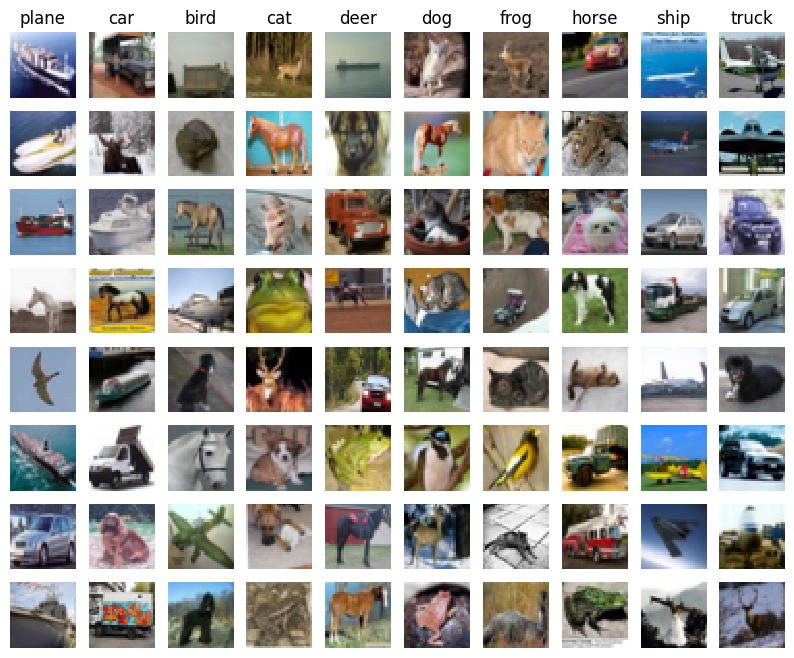

ship -> plane: 29
cat -> dog: 21
plane -> ship: 20
cat -> frog: 16
truck -> car: 15
dog -> cat: 13
cat -> bird: 13
bird -> frog: 12


In [8]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, min(examples_per_class, len(idxs)), replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()
# Summarize the most common errors to support the written analysis.
confusion = np.zeros((10, 10), dtype=int)
np.add.at(confusion, (y_test, y_test_pred), 1)
np.fill_diagonal(confusion, 0)
for flat_index in np.argsort(confusion.ravel())[-8:][::-1]:
    actual, predicted = np.unravel_index(flat_index, confusion.shape)
    print("%s -> %s: %d" % (classes[actual], classes[predicted], confusion[actual, predicted]))


### Inline question 1:
Describe the misclassification results that you see. Do they make sense?


**Answer:** Many errors are understandable from the shared colors, backgrounds, and coarse outlines. The most frequent errors in this test subset are ship -> plane (29), cat -> dog (21), plane -> ship (20), and truck -> car (15). The predicted-plane column includes several boats against blue water/sky, while the predicted-ship column includes aircraft against similar blue backgrounds. Cats and dogs share fur textures and facial shapes, and cars and trucks share strong horizontal and rectangular edges. HOG summarizes local edge directions, and a global hue histogram discards where colors occur; neither fully captures object identity or detailed spatial relationships. Consequently, unrelated objects can also have similar features, especially in these low-resolution images. These are explanations consistent with the displayed mistakes, not proof of the exact cause of each individual prediction.


## Neural Network on image features
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels.

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.

In [9]:
# Preserve the bias-augmented arrays for rerunning Softmax cells.
X_train_nn = X_train_feats[:, :-1]
X_val_nn = X_val_feats[:, :-1]
X_test_nn = X_test_feats[:, :-1]
print('Neural network feature shape:', X_train_nn.shape)


Neural network feature shape:

 (49000, 169)


(Iteration 1 / 6125) loss: 2.492701
(Epoch 0 / 25) train acc: 0.107000; val_acc: 0.128000


(Epoch 1 / 25) train acc: 0.533000; val_acc: 0.518000


(Epoch 2 / 25) train acc: 0.566000; val_acc: 0.544000


(Epoch 3 / 25) train acc: 0.582000; val_acc: 0.556000


(Epoch 4 / 25) train acc: 0.576000; val_acc: 0.577000
(Iteration 1001 / 6125) loss: 1.176566


...

(Epoch 22 / 25) train acc: 0.661000; val_acc: 0.596000


(Epoch 23 / 25) train acc: 0.678000; val_acc: 0.590000


(Epoch 24 / 25) train acc: 0.693000; val_acc: 0.586000


(Iteration 6001 / 6125) loss: 1.057233


(Epoch 25 / 25) train acc: 0.679000; val_acc: 0.592000
hidden=500 lr=0.05 reg=0.001 validation=0.596000
Best neural network validation accuracy: 0.614


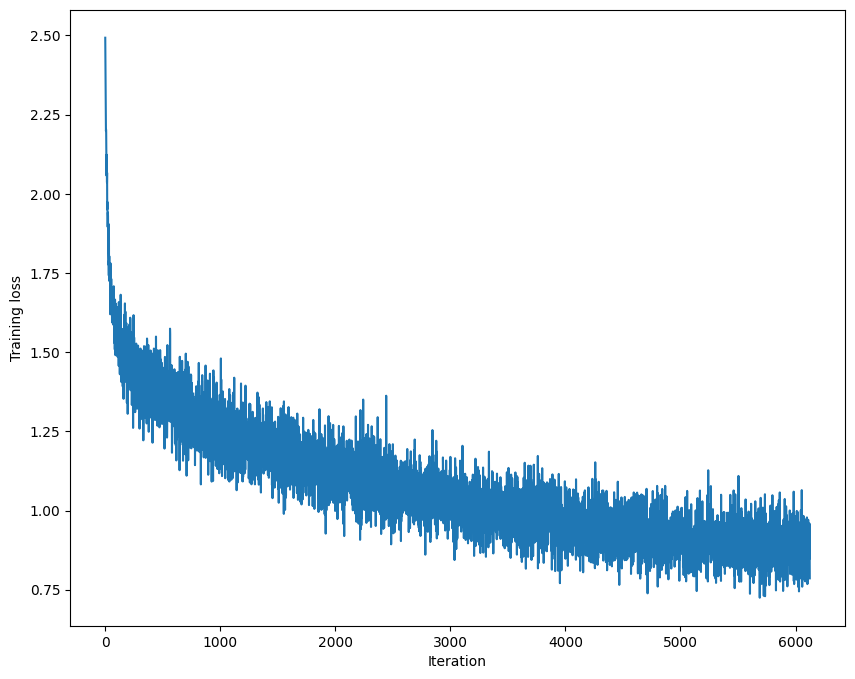

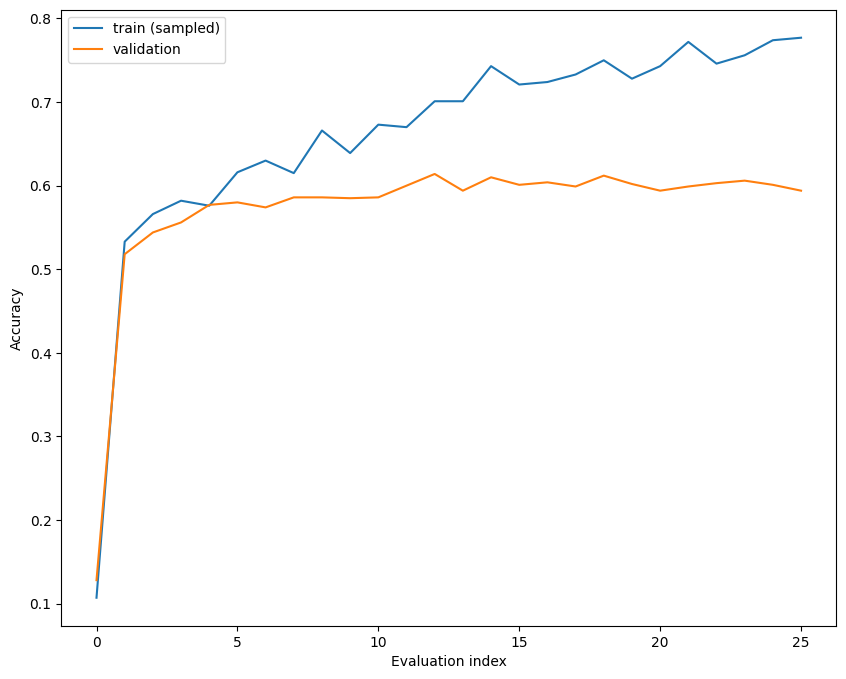

In [10]:
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver
input_dim = X_train_nn.shape[1]
data = {'X_train': X_train_nn, 'y_train': y_train,
        'X_val': X_val_nn, 'y_val': y_val,
        'X_test': X_test_nn, 'y_test': y_test}
configs = [(500, 0.1, 0.001), (500, 0.1, 0.01), (500, 0.05, 0.001)]
best_net = None
best_nn_val = -1
nn_results = {}
for hidden, lr, reg in configs:
    np.random.seed(42)
    net = TwoLayerNet(input_dim, hidden, 10, weight_scale=0.05, reg=reg)
    solver = Solver(net, data, update_rule='sgd',
                    optim_config={'learning_rate': lr}, lr_decay=0.97,
                    num_epochs=25, batch_size=200, print_every=1000)
    solver.train()
    val_acc = solver.check_accuracy(data['X_val'], data['y_val'])
    nn_results[(hidden, lr, reg)] = val_acc
    print('hidden=%d lr=%g reg=%g validation=%f' % (hidden, lr, reg, val_acc))
    if val_acc > best_nn_val:
        best_nn_val, best_net, best_solver = val_acc, net, solver
print('Best neural network validation accuracy:', best_nn_val)
plt.plot(best_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.show()
plt.plot(best_solver.train_acc_history, label='train (sampled)')
plt.plot(best_solver.val_acc_history, label='validation')
plt.xlabel('Evaluation index')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [11]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 58% accuracy. It is also possible to get >60% accuracy
# with careful tuning.

y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)
test_acc = (y_test_pred == data['y_test']).mean()
print(test_acc)

0.571


In [12]:
# Save best model
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy

 saved.
